# Plots notebook

Usage:
- Edit the `results_dir` and `plots_dir` cells below to point to a dataset in the repository.
- Run the cells step-by-step to see which files are produced and if any dependencies or column-name mismatches appear.

In [30]:
from pathlib import Path
import os
import pandas
import plotly.graph_objects as go
import openpyxl

# from synco.plotting.performance import make_performance_plots
# from synco.plotting.performance import make_ring_plots

import plotly.io as pio
pio.get_chrome()

#print working directory
import os
print(os.getcwd())

c:\Users\viviamsb\OneDrive - NTNU\PhD Folder\Pipeline\trafikk_paper\scripts


In [26]:
# SANGER_2024
SCRIPT_DIR = Path.cwd()
PROJECT_ROOT = SCRIPT_DIR.parents[0]   # project/
DATASET_DIR = PROJECT_ROOT / "results" / "Sanger-2024"

BASE = DATASET_DIR / "05_synco"
results_dir = Path(BASE) / 'output'
plots_dir = Path(BASE) /'plots'
show = True  # whether to display interactive figures

plots_dir.mkdir(parents=True, exist_ok=True)

print('results_dir =', results_dir)
print('plots_dir =', plots_dir)

results_dir = c:\Users\viviamsb\OneDrive - NTNU\PhD Folder\Pipeline\trafikk_paper\results\Sanger-2024\05_synco\output
plots_dir = c:\Users\viviamsb\OneDrive - NTNU\PhD Folder\Pipeline\trafikk_paper\results\Sanger-2024\05_synco\plots


## PREPARE DATA

In [27]:
# Load experimental synergy data
synergy_file = PROJECT_ROOT / "data" / "metadata" / "Sanger-2024" / "synergy_data.csv"
synergy_data = pandas.read_csv(synergy_file, sep=',')
n_cell_lines = synergy_data['cell_line'].nunique()
print(f'Number of cell lines in Synergy data: {n_cell_lines}')


# Load Pipeline Drug Profiles (PD) mapping
pd_mapping_file = Path(BASE) / 'input' / 'Drugnames_PD_dict.json'
drugnames_pd_dict = pandas.read_json(pd_mapping_file, typ='series').to_dict()

# Map PD to drug names in synergy data
synergy_data['PD_A'] = synergy_data['drug_name_A'].map(drugnames_pd_dict)
synergy_data['PD_B'] = synergy_data['drug_name_B'].map(drugnames_pd_dict)
# print(f"Synergy data shape before removing missing PD mappings: {synergy_data.shape}")
# Remove rows with missing PD mappings
synergy_data = synergy_data.dropna(subset=['PD_A', 'PD_B'])
synergy_data = synergy_data.reset_index(drop=True)
# print(f"Synergy data shape after removing missing PD mappings: {synergy_data.shape}")

# Format cell line names to match the format in the synergy data
synergy_data['cell_line'] = synergy_data['cell_line'].str.replace('-', '').str.upper()

# Save the processed synergy data to a new CSV file
processed_synergy_file = Path(BASE) / 'input' / 'synergy_PD.csv'
synergy_data.to_csv(processed_synergy_file, index=False)

Number of cell lines in Synergy data: 757


In [29]:
# Count number of cell lines (total and by tissue)
cell_lines_by_tissue = synergy_data.groupby('tissue')['cell_line'].nunique()
print('Cell lines by tissue:')
for tissue_name, count in cell_lines_by_tissue.items():
    print(f'  {tissue_name}: {count}')

Cell lines by tissue:
  Adrenal: 1
  Biliary: 5
  Bladder: 18
  Bone: 35
  Breast: 47
  CNS: 39
  Cervix: 13
  Colon: 43
  Endometrium: 11
  Esophagus: 30
  Head: 27
  Kidney: 17
  Liver: 15
  Lung: 142
  Lymphoid: 133
  Ovary: 31
  PNS: 23
  Pancreas: 30
  Prostate: 7
  Skin: 31
  Soft_tissue: 16
  Stomach: 23
  Testis: 2
  Thyroid: 14
  Uterus: 3
  Vulva: 1


# Multi-Tissue Analysis

This section aggregates results across all tissues and creates comparative visualizations.

In [31]:
# Import multi-tissue plotting module
from synco.plotting.multi_tissue_summary import (
    load_all_tissue_summaries,
    plot_tissue_rings,
    plot_aggregate_ring,
    plot_roc_pr_violin,
    make_multi_tissue_plots
)

In [32]:
# Set paths for multi-tissue analysis
tissues_dir = BASE / "tissues"   # Path to the directory containing all tissue folders
multi_tissue_plots_dir = plots_dir / "multi_tissue_plots"
multi_tissue_plots_dir.mkdir(parents=True, exist_ok=True)

print(f'Tissue results directory: {tissues_dir}')
print(f'Multi-tissue plots directory: {multi_tissue_plots_dir}')

Tissue results directory: c:\Users\viviamsb\OneDrive - NTNU\PhD Folder\Pipeline\trafikk_paper\results\Sanger-2024\05_synco\tissues
Multi-tissue plots directory: c:\Users\viviamsb\OneDrive - NTNU\PhD Folder\Pipeline\trafikk_paper\results\Sanger-2024\05_synco\plots\multi_tissue_plots


## Load All Tissue Data

Load comparison summaries and ROC/PR AUC metrics from all available tissues.

In [45]:
# Load all tissue summaries
comparison_df, roc_auc_df, missing_roc_df = load_all_tissue_summaries(tissues_dir)

print(f'\nLoaded data from {len(comparison_df)} tissues')
print(f'ROC/PR AUC records: {len(roc_auc_df)}')
print(f'\nFirst few tissues:')
print(comparison_df[['tissue', 'Accuracy', 'Precision', 'Recall', 'n_cell_lines']].head())


Loaded data from 26 tissues
ROC/PR AUC records: 757

First few tissues:
    tissue  Accuracy  Precision  Recall  n_cell_lines
0  adrenal     80.00      78.26  100.00             1
1  biliary     72.81      90.54   73.63             5
2  bladder     73.11      81.36   79.65            18
3     bone     72.03      79.12   79.12            35
4   breast     67.41      71.27   79.73            47


In [56]:
comparison_df.to_excel(results_dir / 'multi_tissue_comparison.xlsx', index=False)

## Tissue Ring Plots (Grid)

Show performance rings for all tissues, sorted by accuracy.

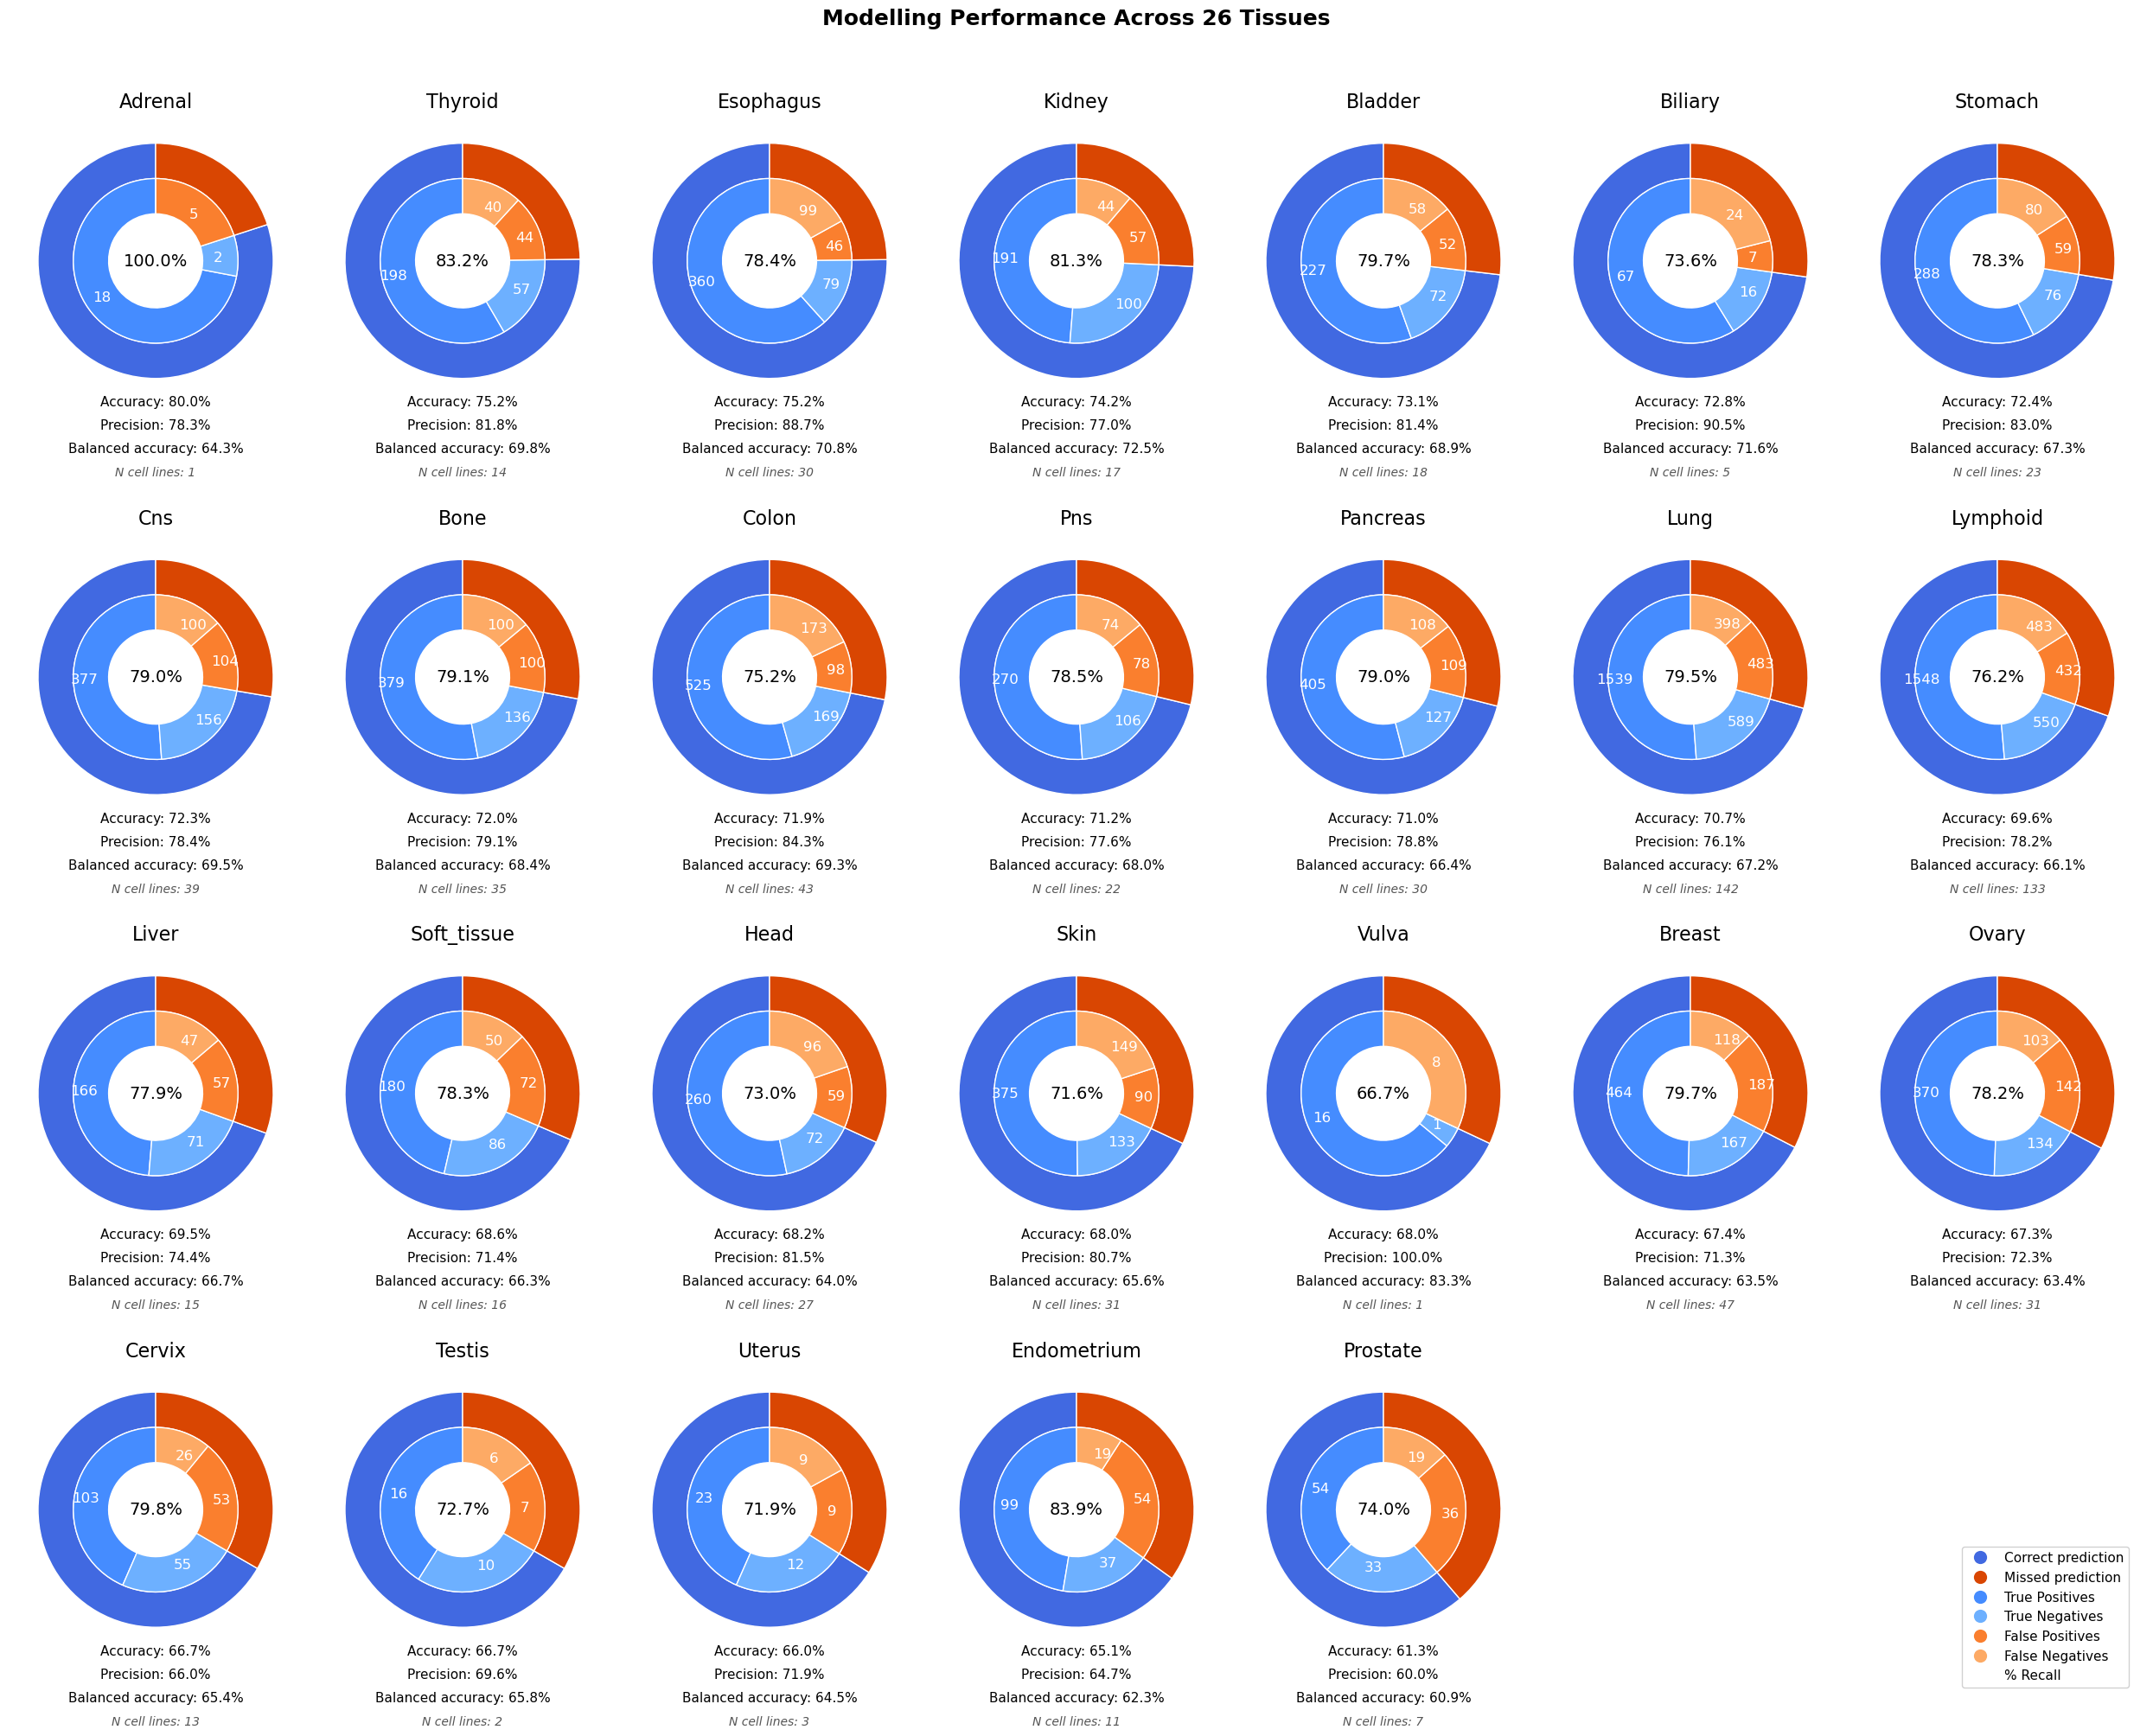

In [46]:
# Generate tissue rings grid (sorted by Accuracy)
fig_grid = plot_tissue_rings(
    comparison_df,
    plots_dir=multi_tissue_plots_dir,
    plot_name='tissue_rings_grid',
    sort_by='Accuracy',
    center_metric='recall',
    ncols=7,
    figsize=(25, 20),
    show=show
)

## Aggregate Ring Plot

Show single aggregate ring combining all tissues.

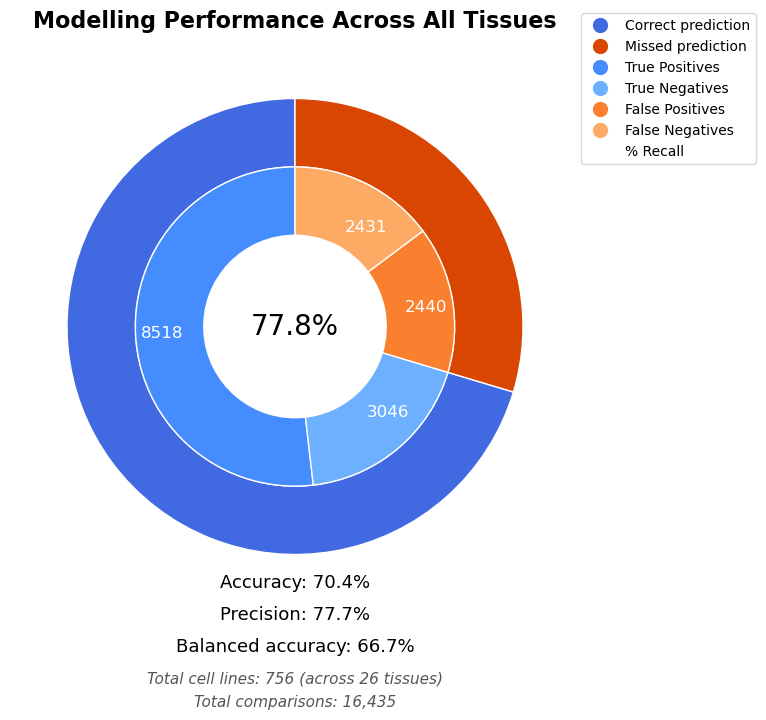

In [48]:
# Generate aggregate ring showing all tissues combined
fig_agg = plot_aggregate_ring(
    comparison_df,
    plots_dir=multi_tissue_plots_dir,
    plot_name='aggregate_ring',
    center_metric='recall',
    figsize=(6, 8),
    show=show
)

## ROC AUC Violin Plot

In [49]:
# ROC AUC violin plot
# Use selected_tissues parameter to filter tissues, or None to show all
fig_roc = plot_roc_pr_violin(
    roc_auc_df,
    plots_dir=multi_tissue_plots_dir,
    plot_name='roc_auc_violin',
    selected_tissues=None,  # None = all tissues, or ['colon', 'breast', 'pancreas'] for specific
    metric='ROC',
    threshold=0.5,
    height=1000,
    show=show
)

In [50]:
roc_auc_df

,tissue,cell_line,roc_auc_score,pr_auc_score,f1_score
0,adrenal,SW13,0.784444,0.898768,0.877193
1,biliary,EGI1,0.937931,0.990619,0.903226
2,biliary,ETK1,0.746667,0.887419,0.827586
3,biliary,HUCCT1,0.521429,0.732976,0.823529
4,biliary,TGBC1TKB,0.388889,0.800977,0.875000
...,...,...,...,...,...
752,thyroid,TT2609C02,0.784211,0.740111,0.625000
753,uterus,MESSA,0.619792,0.594006,0.666667
754,uterus,SKN,0.580247,0.642593,0.615385
755,uterus,SKUT1,0.694444,0.845516,0.758621


## PR AUC Violin Plot

In [51]:
# PR AUC violin plot
# Use selected_tissues parameter to filter tissues, or None to show all
fig_pr = plot_roc_pr_violin(
    roc_auc_df,
    plots_dir=multi_tissue_plots_dir,
    plot_name='roc_auc_violin_selected',
    selected_tissues=['colon', 'ovary', 'lymphoid', 'lung', 'breast', 'pancreas', 'skin'],  # None = all tissues, or ['colon', 'breast', 'pancreas'] for specific
    metric='ROC',
    threshold=0.5,
    width=1000,
    show=show
)

## Accuracy/Recall/Precision Box Plots Across Tissues

This section summarizes Accuracy, Recall, and Precision across tissues using box plots (and a grouped bar overview).

In [52]:
# If multi_tissue results already loaded, reuse; else load and plot
from synco.plotting import multi_tissue_summary as mts
import os

try:
    # Attempt to reuse prior variables if they exist
    _ = comparison_df  # will NameError if not defined
    plots_dir = multi_tissue_plots_dir if 'multi_tissue_plots_dir' in globals() else os.path.join(results_root, 'plots', 'multi_tissue')
    os.makedirs(plots_dir, exist_ok=True)
    fig_box, fig_bar = mts.plot_tissue_metric_boxplots(comparison_df, plots_dir=plots_dir, show=False)
    print('Saved tissue box plots to:', plots_dir)
except NameError:
    # Fallback: load summaries, then plot
    # Configure defaults similar to earlier multi-tissue section
    results_root = results_root if 'results_root' in globals() else os.path.join(os.getcwd(), 'cell_fate')
    tissues_dir = tissues_dir if 'tissues_dir' in globals() else os.path.join(results_root)
    tissues = tissues if 'tissues' in globals() else [p for p in os.listdir(tissues_dir) if os.path.isdir(os.path.join(tissues_dir, p)) and p not in ('synco_input', 'plots')]
    comparison_df, roc_auc_df, missing_roc_df = mts.load_all_tissue_summaries(tissues_dir, tissues=tissues)
    plots_dir = os.path.join(results_root, 'plots', 'multi_tissue')
    os.makedirs(plots_dir, exist_ok=True)
    fig_box, fig_bar = mts.plot_tissue_metric_boxplots(comparison_df, plots_dir=plots_dir, show=False)
    print('Loaded summaries and saved tissue box plots to:', plots_dir)

# Display figures or report saved paths
if hasattr(fig_box, 'show'):
    fig_box.show()
elif isinstance(fig_box, str):
    print('Box plot saved to:', fig_box)

if hasattr(fig_bar, 'show'):
    fig_bar.show()
elif isinstance(fig_bar, str):
    print('Grouped bar plot saved to:', fig_bar)

Saved tissue box plots to: c:\Users\viviamsb\OneDrive - NTNU\PhD Folder\Pipeline\trafikk_paper\results\Sanger-2024\05_synco\plots\multi_tissue_plots
Box plot saved to: box
Grouped bar plot saved to: bar


## F1 / ROC AUC / PR AUC Box & Bar Across Tissues

Summarizes F1 Score, ROC AUC, and PR AUC across tissues with box plots and grouped bar overview.

In [53]:
# If multi_tissue ROC/PR results already loaded, reuse; else load and plot
from synco.plotting import multi_tissue_summary as mts
import os


_ = roc_auc_df  # NameError if not defined
plots_dir = multi_tissue_plots_dir if 'multi_tissue_plots_dir' in globals() else os.path.join(results_root, 'plots', 'multi_tissue')
os.makedirs(plots_dir, exist_ok=True)
figs = mts.plot_tissue_roc_pr_f1(roc_auc_df, plots_dir=plots_dir, show=False, tissue_color=False,
                                          figsize_box=(700, 800),
                                          figsize_bar=(1500, 500),
                                          figsize_heatmap=(550, 700)
                                          )
print('Saved ROC/PR/F1 tissue plots to:', plots_dir)

# Display figures inline if returned as Plotly objects
# box_fig = figs.get('box') if isinstance(figs, dict) else None
bar_fig = figs.get('bar') if isinstance(figs, dict) else None
heatmap_fig = figs.get('heatmap') if isinstance(figs, dict) else None
# if hasattr(box_fig, 'show'):
#     box_fig.show()
# if hasattr(bar_fig, 'show'):
#     bar_fig.show()
if hasattr(heatmap_fig, 'show'):
    heatmap_fig.show()

Saved ROC/PR/F1 tissue plots to: c:\Users\viviamsb\OneDrive - NTNU\PhD Folder\Pipeline\trafikk_paper\results\Sanger-2024\05_synco\plots\multi_tissue_plots


## Collect classification metrics

In [66]:
def collect_synco_results(
    tissues_dir: str | Path,
    output_file: str | Path | None = None,
) -> pandas.DataFrame:
    """
    Collect and merge Synco results from:

    tissues/
        tissue_name/
            synco_output/
                cell_line_comparison_results.csv
                roc_metrics_df.csv

    Returns one row per tissue-cell line.
    """
    tissues_dir = Path(tissues_dir)
    merged_tables = []

    for tissue_dir in sorted(tissues_dir.iterdir()):
        if not tissue_dir.is_dir():
            continue

        synco_dir = tissue_dir / "synco_output"
        comparison_file = synco_dir / "cell_line_comparison_results.csv"
        roc_file = synco_dir / "roc_metrics_df.csv"

        if not comparison_file.exists() or not roc_file.exists():
            print(f"Skipping {tissue_dir.name}: missing Synco output file")
            continue

        # Cell-line classification metrics
        comparison_df = pandas.read_csv(comparison_file)

        # The first unnamed column contains the cell-line names
        unnamed_columns = [
            column
            for column in comparison_df.columns
            if column.startswith("Unnamed:")
        ]

        if "cell_line" not in comparison_df.columns:
            if not unnamed_columns:
                raise ValueError(
                    f"No cell-line column found in {comparison_file}"
                )

            comparison_df = comparison_df.rename(
                columns={unnamed_columns[0]: "cell_line"}
            )

        comparison_df = comparison_df.drop(
            columns=[
                column
                for column in comparison_df.columns
                if column.startswith("Unnamed:")
            ],
            errors="ignore",
        )

        # ROC, PR and F1 metrics
        roc_df = pandas.read_csv(roc_file)

        roc_df = roc_df.drop(
            columns=[
                column
                for column in roc_df.columns
                if column.startswith("Unnamed:")
            ],
            errors="ignore",
        )

        if "cell_line" not in roc_df.columns:
            raise ValueError(f"No cell_line column found in {roc_file}")

        # Clean identifiers before merging
        comparison_df["cell_line"] = (
            comparison_df["cell_line"].astype(str).str.strip()
        )
        roc_df["cell_line"] = roc_df["cell_line"].astype(str).str.strip()

        tissue_results = comparison_df.merge(
            roc_df,
            on="cell_line",
            how="outer",
            validate="one_to_one",
        )

        tissue_results.insert(1, "tissue", tissue_dir.name)
        merged_tables.append(tissue_results)

    if not merged_tables:
        raise ValueError(f"No complete Synco result folders found in {tissues_dir}")

    combined_df = pandas.concat(merged_tables, ignore_index=True)

    desired_columns = [
        "cell_line",
        "tissue",
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative",
        "Total",
        "Match",
        "Mismatch",
        "Match %",
        "Mismatch %",
        "Accuracy",
        "Recall",
        "Precision",
        "balanced_accuracy",
        "failure_reason",
        "roc_auc",
        "pr_auc",
        "f1_score",
        "n_positive",
        "n_negative",
        "pred_min",
        "valid_matched_rows",
        "missing_predictions",
        "invalid_experimental_values",
        "invalid_predictions"
    ]

    # Keep the requested columns that actually exist
    existing_columns = [
        column for column in desired_columns if column in combined_df.columns
    ]
    combined_df = combined_df[existing_columns]

    combined_df = combined_df.sort_values(
        ["tissue", "cell_line"]
    ).reset_index(drop=True)

    if output_file is not None:
        output_file = Path(output_file)
        output_file.parent.mkdir(parents=True, exist_ok=True)
        combined_df.to_csv(output_file, index=False)

    return combined_df

In [68]:
classification_results_df = collect_synco_results(
    tissues_dir=tissues_dir,
    output_file=results_dir / "synco_clines_details.csv",
)
classification_results_df.to_excel(results_dir / "synco_clines_details.xlsx", index=False)
print(classification_results_df.shape)
classification_results_df

(757, 26)


,cell_line,tissue,True Positive,True Negative,False Positive,False Negative,Total,Match,Mismatch,Match %,...,roc_auc,pr_auc,f1_score,n_positive,n_negative,pred_min,valid_matched_rows,missing_predictions,invalid_experimental_values,invalid_predictions
0,SW13,adrenal,18.0,2.0,5.0,0.0,25.0,20.0,5.0,80.000000,...,0.784444,0.898768,0.877193,25.0,9.0,-0.403736,34,0,0,0
1,EGI1,biliary,15.0,5.0,0.0,5.0,25.0,20.0,5.0,80.000000,...,0.937931,0.990619,0.903226,29.0,5.0,-0.499411,34,0,0,0
2,ETK1,biliary,14.0,4.0,2.0,5.0,25.0,18.0,7.0,72.000000,...,0.746667,0.887419,0.827586,25.0,9.0,-0.500361,34,0,0,0
3,HUCCT1,biliary,13.0,3.0,4.0,5.0,25.0,16.0,9.0,64.000000,...,0.521429,0.732976,0.823529,21.0,10.0,-0.546736,31,0,0,0
4,TGBC1TKB,biliary,8.0,1.0,1.0,4.0,14.0,9.0,5.0,64.285714,...,0.388889,0.800977,0.875000,15.0,3.0,-0.440282,18,16,0,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
752,TT2609C02,thyroid,12.0,8.0,5.0,0.0,25.0,20.0,5.0,80.000000,...,0.784211,0.740111,0.625000,15.0,19.0,-0.500354,34,0,0,0
753,MESSA,uterus,11.0,7.0,3.0,4.0,25.0,18.0,7.0,72.000000,...,0.619792,0.594006,0.666667,18.0,16.0,-0.433485,34,0,0,0
754,SKN,uterus,5.0,3.0,4.0,2.0,14.0,8.0,6.0,57.142857,...,0.580247,0.642593,0.615385,9.0,9.0,-0.440282,18,16,0,11
755,SKUT1,uterus,7.0,2.0,2.0,3.0,14.0,9.0,5.0,64.285714,...,0.694444,0.845516,0.758621,12.0,6.0,-0.437574,18,16,0,11


In [69]:
# Collect all cell-line classification results with ROC-AUC < 0.5
low_roc_df = classification_results_df[classification_results_df['roc_auc'] < 0.5].copy()
low_roc_df.to_csv(results_dir / "synco_clines_low_roc.csv", index=False)
low_roc_df.to_excel(results_dir / "synco_clines_low_roc.xlsx", index=False)